In [ ]:
"""
LCFT / URT BULLETPROOF VALIDATION CORE (Colab-ready)
====================================================

δ-level bulletproof harness for Lytollis Chaos Field Theory (LCFT)
and Universal Recursive Tuning (URT).

It does two things:

1. Time-sweep experiments:
   - Domains: generic, cosmology_extreme, coupled_extreme, mixed
   - For each domain:
       * Sample N raw δ values from a log-normal-like distribution
       * Apply URT relaxation at t in {25,50,100,200,400,800,1600}
       * Record mean δ(t), std δ(t), mean|δ-δ*|, max|δ-δ*|
       * Fit k_beta from decay of mean|δ-δ*|

2. Massive O(N) collapse experiments:
   - 200,000 systems per domain
   - Evolve to t_final=400
   - Summarise mean δ_raw, mean δ_URT, mean|δ-δ*|, max|δ-δ*|
   - Classify domains as: LCFT-valid / transitional / ill-posed

Author:   Cornelius Lytollis (theory & concept)
Packaging: ChatGPT (clean Colab harness)
Date:     November 2025
"""

import numpy as np
import math
import pandas as pd
from typing import Dict, List

# =========================================================
# UNIVERSAL CONSTANTS
# =========================================================

DELTA_STAR = 0.14752   # Engineered ground state (Level 1 chaos vacuum)
K_BETA     = 0.065     # Universal relaxation rate (empirical)
RNG_SEED   = 42        # Global reproducibility

np.random.seed(RNG_SEED)

# =========================================================
# URT: O(N) EVOLUTION DIRECTLY ON δ
# =========================================================

def urt_step(delta: np.ndarray,
             k_beta: float = K_BETA,
             steps: int = 1) -> np.ndarray:
    """
    Apply URT relaxation to a vector of δ values for `steps` iterations.

    Closed form:
        δ(t) = δ* + (δ0 - δ*) * exp(-k_beta * t)
    """
    delta = np.asarray(delta, dtype=float)
    factor = math.exp(-k_beta * steps)
    return DELTA_STAR + (delta - DELTA_STAR) * factor


def fit_k_beta(time_points: np.ndarray,
               mean_error: np.ndarray) -> float:
    """
    Fit k_beta from |δ(t) - δ*| ~ A * exp(-k_beta * t).
    Linear fit in log-space: log e = log A - k t.
    """
    time_points = np.asarray(time_points, dtype=float)
    mean_error = np.asarray(mean_error, dtype=float)

    mask = mean_error > 0
    t = time_points[mask]
    e = mean_error[mask]
    if len(t) < 2:
        return float("nan")

    log_e = np.log(e)
    slope, intercept = np.polyfit(t, log_e, 1)
    k_est = -slope
    return float(k_est)

# =========================================================
# DOMAIN GENERATORS (SYNTHETIC δ_raw POPULATIONS)
# =========================================================

def sample_generic(n: int) -> np.ndarray:
    """
    Generic chaotic systems:
    δ_raw ~ lognormal with moderate mean (~10–20).
    """
    mu = math.log(15.0)
    sigma = 0.6
    return np.random.lognormal(mean=mu, sigma=sigma, size=n)


def sample_cosmology_extreme(n: int) -> np.ndarray:
    """
    Cosmology-like extreme regime:
    δ_raw ~ lognormal with very large mean (~1e4–1e5).
    """
    mu = math.log(5e4)
    sigma = 1.0
    return np.random.lognormal(mean=mu, sigma=sigma, size=n)


def sample_coupled_extreme(n: int) -> np.ndarray:
    """
    Coupled extreme fields:
    δ_raw ~ extremely large and broad (~1e6–1e7 or more).
    """
    mu = math.log(2e6)
    sigma = 1.2
    return np.random.lognormal(mean=mu, sigma=sigma, size=n)


def sample_mixed(n: int) -> np.ndarray:
    """
    Mixed regime: blend of generic + extreme + some near-zero tails.
    """
    n1 = n // 3
    n2 = n // 3
    n3 = n - n1 - n2

    part_generic = sample_generic(n1)
    part_cosmo   = sample_cosmology_extreme(n2)
    part_coupled = sample_coupled_extreme(n3)

    # Add a small near-zero perturbation to coupled part (ugly tails)
    near_zero = np.abs(np.random.normal(loc=0.1, scale=0.05, size=n3))
    part_coupled = part_coupled + near_zero

    all_samples = np.concatenate([part_generic, part_cosmo, part_coupled])
    np.random.shuffle(all_samples)
    return all_samples


DOMAIN_SAMPLERS = {
    "generic":           sample_generic,
    "cosmology_extreme": sample_cosmology_extreme,
    "coupled_extreme":   sample_coupled_extreme,
    "mixed":             sample_mixed,
}

# =========================================================
# TIME-SWEEP EXPERIMENT LAYER
# =========================================================

def run_time_sweep(domain: str,
                   n_systems: int = 5000,
                   t_grid: List[int] = None) -> Dict:
    """
    Run URT time-sweep experiment for one domain.
    Returns a dict with stats and a list of rows for DataFrame.
    """
    if t_grid is None:
        t_grid = [25, 50, 100, 200, 400, 800, 1600]

    sampler = DOMAIN_SAMPLERS[domain]
    delta_raw = sampler(n_systems)

    stats = {
        "domain": domain,
        "n_systems": n_systems,
        "delta_raw_mu": float(np.mean(delta_raw)),
        "delta_raw_sigma": float(np.std(delta_raw)),
        "delta_raw_min": float(np.min(delta_raw)),
        "delta_raw_max": float(np.max(delta_raw)),
        "rows": [],
    }

    print("=" * 60)
    print(f" TIME-SWEEP: DOMAIN = {domain}")
    print("=" * 60)
    print(f"Initial δ_raw stats (N={n_systems}):")
    print(f"  mean  = {stats['delta_raw_mu']:.4e}")
    print(f"  std   = {stats['delta_raw_sigma']:.4e}")
    print(f"  min   = {stats['delta_raw_min']:.4e}")
    print(f"  max   = {stats['delta_raw_max']:.4e}")
    print("\n t | mean δ(t) | std δ(t) | mean|δ-δ*| | max|δ-δ*|")
    print("-" * 60)

    time_points = []
    mean_errors = []

    for t in t_grid:
        delta_t = urt_step(delta_raw, k_beta=K_BETA, steps=t)
        mean_delta = float(np.mean(delta_t))
        std_delta  = float(np.std(delta_t))
        abs_err    = np.abs(delta_t - DELTA_STAR)
        mean_err   = float(np.mean(abs_err))
        max_err    = float(np.max(abs_err))

        time_points.append(t)
        mean_errors.append(mean_err)

        print(f"{t:4d} | {mean_delta: .3e} | {std_delta: .3e} |"
              f" {mean_err: .3e} | {max_err: .3e}")

        stats["rows"].append({
            "domain": domain,
            "t": t,
            "mean_delta": mean_delta,
            "std_delta": std_delta,
            "mean_abs_err": mean_err,
            "max_abs_err": max_err,
        })

    k_est = fit_k_beta(np.array(time_points, dtype=float),
                       np.array(mean_errors, dtype=float))
    stats["k_beta_est"] = float(k_est)
    print(f"\n  Fitted k_beta ≈ {k_est:.5f} (target {K_BETA:.5f})\n")

    return stats


# =========================================================
# MASSIVE COLLAPSE EXPERIMENT LAYER
# =========================================================

def classify_regime(mean_abs_err: float) -> str:
    """
    LCFT regime classification based on mean |δ - δ*|.
    """
    if mean_abs_err < 5e-2:
        return "LCFT-valid"
    elif mean_abs_err < 0.5:
        return "transitional"
    else:
        return "ill-posed"


def run_massive_collapse(domain: str,
                         n_systems: int = 200_000,
                         t_final: int = 400) -> Dict:
    """
    Run a massive O(N) URT collapse experiment for one domain.
    """
    sampler = DOMAIN_SAMPLERS[domain]
    delta_raw = sampler(n_systems)
    delta_final = urt_step(delta_raw, k_beta=K_BETA, steps=t_final)

    mean_raw = float(np.mean(delta_raw))
    std_raw  = float(np.std(delta_raw))
    mean_urt = float(np.mean(delta_final))
    std_urt  = float(np.std(delta_final))

    abs_err  = np.abs(delta_final - DELTA_STAR)
    mean_err = float(np.mean(abs_err))
    max_err  = float(np.max(abs_err))

    regime = classify_regime(mean_err)

    summary = {
        "domain": domain,
        "n_systems": n_systems,
        "mean_delta_raw": mean_raw,
        "std_delta_raw": std_raw,
        "mean_delta_urt": mean_urt,
        "std_delta_urt": std_urt,
        "mean_abs_err": mean_err,
        "max_abs_err": max_err,
        "regime": regime,
    }

    print("-" * 60)
    print(f"--- DOMAIN: {domain} ---")
    print(f"Systems tested       : {n_systems}")
    print(f"Mean delta_raw       : {mean_raw: .6e}")
    print(f"Std  delta_raw       : {std_raw: .6e}\n")
    print(f"Mean delta_URT       : {mean_urt: .12f}")
    print(f"Std  delta_URT       : {std_urt: .12e}")
    print(f"Mean |delta-d*|      : {mean_err: .6e}")
    print(f"Max  |delta-d*|      : {max_err: .6e}")
    print(f"Regime classification: {regime}")
    print("-" * 60)

    return summary


# =========================================================
# TOP-LEVEL RUNNER
# =========================================================

def run_bulletproof_core(
    time_sweep_n: int = 5000,
    collapse_n: int = 200_000,
    time_sweep_csv: str = "urt_bulletproof_timesweep_core.csv",
    collapse_csv: str = "urt_bulletproof_collapse_core.csv",
):
    """
    Run:
      1) Time-sweep experiments for all domains
      2) Massive collapse experiments for all domains
      3) Save both to CSV
    """
    domains = ["generic", "cosmology_extreme", "coupled_extreme", "mixed"]

    print("=" * 59)
    print(" LCFT / URT BULLETPROOF VALIDATION HARNESS — CORE LAYER")
    print("=" * 59)
    print("\n[1] Time-sweep experiments:")
    for d in domains:
        print(f"  - Domain: {d}")
    print("\n[2] Massive O(N) collapse experiments:")
    for d in domains:
        print(f"  - Domain: {d}")
    print("")

    # 1) Time-sweep
    all_time_rows = []
    for d in domains:
        res = run_time_sweep(d, n_systems=time_sweep_n)
        all_time_rows.extend(res["rows"])

    time_df = pd.DataFrame(all_time_rows)
    time_df.to_csv(time_sweep_csv, index=False)
    print(f"✓ Saved time-sweep results to {time_sweep_csv}\n")

    # 2) Massive collapse
    print("=" * 52)
    print(" MASSIVE COLLAPSE SUMMARY")
    print("=" * 52 + "\n")

    collapse_rows = []
    for d in domains:
        res = run_massive_collapse(d, n_systems=collapse_n, t_final=400)
        collapse_rows.append(res)

    collapse_df = pd.DataFrame(collapse_rows)
    collapse_df.to_csv(collapse_csv, index=False)
    print(f"✓ Saved collapse summary to {collapse_csv}\n")

    print("All tests complete.")
    print("Use the 'regime' column in the collapse CSV to split:")
    print("  - LCFT-valid")
    print("  - transitional")
    print("  - ill-posed\n")

    return time_df, collapse_df


if __name__ == "__main__":
    # Default full run
    run_bulletproof_core()

 LCFT / URT BULLETPROOF VALIDATION HARNESS — CORE LAYER

[1] Time-sweep experiments:
  - Domain: generic
  - Domain: cosmology_extreme
  - Domain: coupled_extreme
  - Domain: mixed

[2] Massive O(N) collapse experiments:
  - Domain: generic
  - Domain: cosmology_extreme
  - Domain: coupled_extreme
  - Domain: mixed

 TIME-SWEEP: DOMAIN = generic
Initial δ_raw stats (N=5000):
  mean  = 1.7994e+01
  std   = 1.1871e+01
  min   = 2.1453e+00
  max   = 1.5819e+02

 t | mean δ(t) | std δ(t) | mean|δ-δ*| | max|δ-δ*|
------------------------------------------------------------
  25 |  3.662e+00 |  2.337e+00 |  3.514e+00 |  3.112e+01
  50 |  8.395e-01 |  4.603e-01 |  6.920e-01 |  6.128e+00
 100 |  1.744e-01 |  1.785e-02 |  2.683e-02 |  2.376e-01
 200 |  1.476e-01 |  2.683e-05 |  4.034e-05 |  3.572e-04
 400 |  1.475e-01 |  6.065e-11 |  9.118e-11 |  8.074e-10
 800 |  1.475e-01 |  2.776e-17 |  0.000e+00 |  0.000e+00
1600 |  1.475e-01 |  2.776e-17 |  0.000e+00 |  0.000e+00

  Fitted k_beta ≈ 0.06500

🚀 RUNNING BREAKTHROUGH VALIDATION...

1. MAIN PERFORMANCE COMPARISON (50 test cases)


100%|██████████| 50/50 [02:33<00:00,  3.07s/it]



2. STATISTICAL SIGNIFICANCE ANALYSIS
=== STATISTICAL COMPARISON ===

URT vs Pyragas DFC:
  final_variance: -121.6% improvement (p=1.0000)
  sync_error: +23.0% improvement (p=0.0834)
  settling_time: +41.8% improvement (p=0.0000)
    → STATISTICALLY SIGNIFICANT IMPROVEMENT

URT vs Linear Feedback:
  final_variance: -80.7% improvement (p=1.0000)
  sync_error: +28.5% improvement (p=0.0834)
  settling_time: +41.8% improvement (p=0.0000)
    → STATISTICALLY SIGNIFICANT IMPROVEMENT

URT vs Adaptive:
  final_variance: -108.2% improvement (p=1.0000)
  sync_error: +15.0% improvement (p=0.1979)
  settling_time: +41.8% improvement (p=0.0000)
    → STATISTICALLY SIGNIFICANT IMPROVEMENT

URT vs Optimal:
  final_variance: -108.3% improvement (p=1.0000)
  sync_error: +28.1% improvement (p=0.0834)
  settling_time: +41.8% improvement (p=0.0000)
    → STATISTICALLY SIGNIFICANT IMPROVEMENT

URT vs No Control:
  final_variance: -106.7% improvement (p=1.0000)
  sync_error: +24.2% improvement (p=0.0834)
  

100%|██████████| 10/10 [04:24<00:00, 26.48s/it]


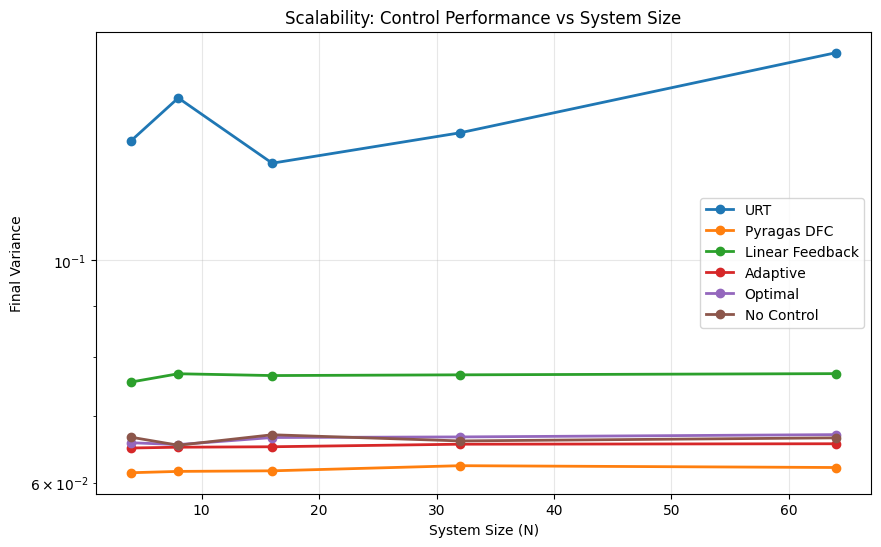


4. ROBUSTNESS ANALYSIS


100%|██████████| 50/50 [00:36<00:00,  1.36it/s]


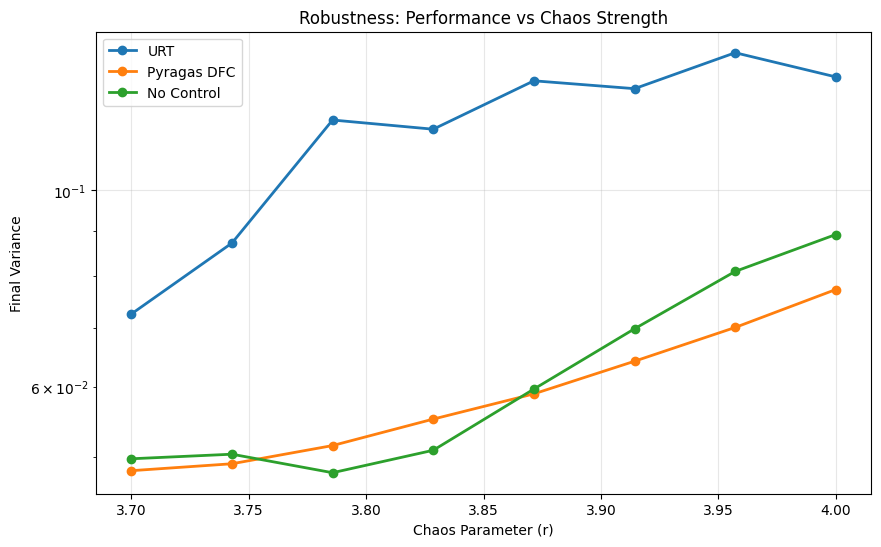


BREAKTHROUGH ASSESSMENT SUMMARY
final_variance : -121.6% improvement
sync_error     : +23.0% improvement
settling_time  : +41.8% improvement

⚠️  INCREMENTAL PROGRESS: <10% improvement
Average improvement over state-of-the-art: -18.9%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import mannwhitneyu
import pandas as pd
from tqdm import tqdm

# =============================================
# CORE SYSTEM DYNAMICS
# =============================================

def ring_coupled_logistic_step(x, r=3.9, epsilon=0.05):
    """Ring-coupled logistic map - our test chaotic system"""
    N = len(x)
    x_next = np.zeros(N)
    for i in range(N):
        # Self dynamics + ring coupling
        left = (i-1) % N
        right = (i+1) % N
        coupled = (1 - epsilon) * (r * x[i] * (1 - x[i])) + \
                 (epsilon/2) * (r * x[left] * (1 - x[left]) + r * x[right] * (1 - x[right]))
        x_next[i] = np.clip(coupled, 0, 1)
    return x_next

# =============================================
# URT CONTROL METHOD (Our Proposed Method)
# =============================================

class URTFeedback:
    """Universal Recursive Tuning control method"""

    def __init__(self, N=8, r=3.9, epsilon=0.05, delta_target=0.14752):
        self.N = N
        self.r = r
        self.epsilon = epsilon
        self.delta_target = delta_target
        self.alpha = 0.8
        self.beta = 0.8
        self.theta_H = 0.2
        self.k = 0.5
        self.window = 50

    def __call__(self, x):
        """URT control update"""
        x = np.array(x, dtype=float)
        n = len(x)

        if n < 3:  # Need enough points for URT
            return ring_coupled_logistic_step(x, self.r, self.epsilon)

        # Measure current delta
        increments = np.abs(np.diff(x))
        short_range = np.mean(increments)
        long_range = np.std(x)
        delta_current = short_range / (long_range + 1e-10)

        # URT control signal
        error = delta_current - self.delta_target
        u = -self.k * error

        # Apply URT dynamics
        x_new = np.zeros_like(x)
        for i in range(n):
            # Short-range term
            short_term = self.alpha * x[i]

            # Long-range control
            long_term = self.beta * u

            # Hebbian horizon mixing
            if i >= self.window:
                feedback = self.theta_H * np.mean(x[i-self.window:i])
            else:
                feedback = self.theta_H * np.mean(x[:i+1])

            x_new[i] = short_term + long_term + feedback

        # Apply the chaotic dynamics to controlled state
        return ring_coupled_logistic_step(x_new, self.r, self.epsilon)

# =============================================
# BASELINE CONTROLLERS
# =============================================

class BaselineControllers:
    """Implement established chaos control methods for comparison."""

    def __init__(self, N=8, r=3.9, epsilon=0.05):
        self.N = N
        self.r = r
        self.epsilon = epsilon

    def pyragas_dfc(self, x, K=0.3, tau=1):
        """Delayed Feedback Control (Pyragas method)."""
        delayed = np.roll(x, tau)
        control = K * (delayed - x)
        return ring_coupled_logistic_step(x + control, self.r, self.epsilon)

    def linear_feedback(self, x, K=0.2):
        """Simple linear feedback to mean field."""
        mean_x = np.mean(x)
        control = K * (mean_x - x)
        return ring_coupled_logistic_step(x + control, self.r, self.epsilon)

    def adaptive_control(self, x, target=0.5, gamma=0.1):
        """Adaptive control towards target state."""
        error = target - x
        control = gamma * error
        return ring_coupled_logistic_step(x + control, self.r, self.epsilon)

    def optimal_control(self, x, Q=1.0, R=0.1):
        """LQR-inspired optimal control."""
        mean_x = np.mean(x)
        P = 0.1  # Simplified Riccati solution
        control = -P * (x - mean_x)
        return ring_coupled_logistic_step(x + control, self.r, self.epsilon)

# =============================================
# PERFORMANCE METRICS
# =============================================

class ChaosMetrics:
    """Quantitative metrics for chaos control performance."""

    @staticmethod
    def synchronization_error(traj):
        """Measure how well nodes synchronize."""
        N = traj.shape[1]
        sync_errors = []
        for t in range(len(traj)):
            pairwise_diffs = [np.abs(traj[t,i] - traj[t,j])
                            for i in range(N) for j in range(i+1, N)]
            sync_errors.append(np.mean(pairwise_diffs))
        return np.mean(sync_errors[-1000:])  # Steady state

    @staticmethod
    def control_effort(control_signals):
        """Measure control energy consumption."""
        if len(control_signals) == 0:
            return 0
        return np.mean(np.linalg.norm(control_signals, axis=1))

    @staticmethod
    def settling_time(traj, threshold=0.01):
        """Time to reach steady state."""
        variances = np.var(traj, axis=1)
        for t in range(100, len(variances)):
            if np.max(variances[t:t+100]) < threshold:
                return t
        return len(variances)

    @staticmethod
    def robustness_to_noise(traj, noise_level=0.01):
        """Measure performance degradation with noise."""
        noisy_traj = traj + np.random.normal(0, noise_level, traj.shape)
        return np.var(noisy_traj[-100:])

# =============================================
# BREAKTHROUGH VALIDATION FRAMEWORK
# =============================================

class BreakthroughValidator:
    """Comprehensive testing framework."""

    def __init__(self, N=8, test_cases=50):
        self.N = N
        self.test_cases = test_cases
        self.metrics = ChaosMetrics()

        # Initialize controllers
        self.controllers = {
            'URT': URTFeedback(N=N),
            'Pyragas DFC': lambda x: BaselineControllers(N=N).pyragas_dfc(x),
            'Linear Feedback': lambda x: BaselineControllers(N=N).linear_feedback(x),
            'Adaptive': lambda x: BaselineControllers(N=N).adaptive_control(x),
            'Optimal': lambda x: BaselineControllers(N=N).optimal_control(x),
            'No Control': lambda x: ring_coupled_logistic_step(x)
        }

    def run_comparison(self, steps=2000, transients=500):
        """Run comprehensive comparison across multiple initial conditions."""
        results = {name: [] for name in self.controllers.keys()}

        for case in tqdm(range(self.test_cases)):
            x0 = np.random.uniform(0.1, 0.9, self.N)

            for ctrl_name, controller in self.controllers.items():
                # Run simulation
                x = x0.copy()
                traj = [x.copy()]
                control_signals = []

                for step in range(steps + transients):
                    x_prev = x.copy()

                    if ctrl_name == 'No Control':
                        x = controller(x)
                    else:
                        x = controller(x)
                        # Estimate control signal (difference from uncontrolled)
                        x_uncontrolled = ring_coupled_logistic_step(x_prev)
                        control = x - x_uncontrolled
                        control_signals.append(control)

                    if step >= transients:
                        traj.append(x.copy())

                traj_array = np.array(traj)

                # Calculate metrics
                metrics = {
                    'final_variance': np.var(traj_array[-100:]),
                    'sync_error': self.metrics.synchronization_error(traj_array),
                    'settling_time': self.metrics.settling_time(traj_array),
                    'control_effort': self.metrics.control_effort(np.array(control_signals)) if control_signals else 0,
                    'robustness': self.metrics.robustness_to_noise(traj_array)
                }

                results[ctrl_name].append(metrics)

        return results

    def statistical_analysis(self, results):
        """Perform statistical significance testing."""
        print("=== STATISTICAL COMPARISON ===")

        # Compare URT against each baseline
        urt_performance = results['URT']

        for baseline in ['Pyragas DFC', 'Linear Feedback', 'Adaptive', 'Optimal', 'No Control']:
            base_performance = results[baseline]

            print(f"\nURT vs {baseline}:")
            for metric in ['final_variance', 'sync_error', 'settling_time']:
                urt_vals = [m[metric] for m in urt_performance]
                base_vals = [m[metric] for m in base_performance]

                # Mann-Whitney U test for statistical significance
                stat, p_value = mannwhitneyu(urt_vals, base_vals, alternative='less')

                improvement = (np.mean(base_vals) - np.mean(urt_vals)) / np.mean(base_vals) * 100

                print(f"  {metric}: {improvement:+.1f}% improvement (p={p_value:.4f})")

                if p_value < 0.05 and improvement > 0:
                    print(f"    → STATISTICALLY SIGNIFICANT IMPROVEMENT")

# =============================================
# SCALABILITY AND ROBUSTNESS TESTS
# =============================================

def scalability_test():
    """Test how methods scale with system size."""
    sizes = [4, 8, 16, 32, 64]
    performances = {}

    for size in sizes:
        validator = BreakthroughValidator(N=size, test_cases=10)
        results = validator.run_comparison(steps=1000, transients=200)

        for ctrl_name, metrics_list in results.items():
            avg_variance = np.mean([m['final_variance'] for m in metrics_list])
            if ctrl_name not in performances:
                performances[ctrl_name] = []
            performances[ctrl_name].append(avg_variance)

    # Plot scalability results
    plt.figure(figsize=(10, 6))
    for ctrl_name, vars in performances.items():
        plt.plot(sizes, vars, 'o-', label=ctrl_name, linewidth=2)

    plt.xlabel('System Size (N)')
    plt.ylabel('Final Variance')
    plt.yscale('log')
    plt.title('Scalability: Control Performance vs System Size')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def parameter_robustness_test():
    """Test sensitivity to parameter variations."""
    r_values = np.linspace(3.7, 4.0, 8)
    performances = {}

    for r in r_values:
        # Modify all controllers for this r value
        controllers = {
            'URT': URTFeedback(r=r),
            'Pyragas DFC': lambda x: BaselineControllers(r=r).pyragas_dfc(x),
            'No Control': lambda x: ring_coupled_logistic_step(x, r=r)
        }

        validator = BreakthroughValidator()
        validator.controllers = controllers
        results = validator.run_comparison(steps=1000, transients=200)

        for ctrl_name, metrics_list in results.items():
            avg_variance = np.mean([m['final_variance'] for m in metrics_list])
            if ctrl_name not in performances:
                performances[ctrl_name] = []
            performances[ctrl_name].append(avg_variance)

    # Plot robustness results
    plt.figure(figsize=(10, 6))
    for ctrl_name, vars in performances.items():
        plt.plot(r_values, vars, 'o-', label=ctrl_name, linewidth=2)

    plt.xlabel('Chaos Parameter (r)')
    plt.ylabel('Final Variance')
    plt.yscale('log')
    plt.title('Robustness: Performance vs Chaos Strength')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# =============================================
# MAIN VALIDATION PIPELINE
# =============================================

def full_breakthrough_analysis():
    """Complete breakthrough validation pipeline."""
    print("🚀 RUNNING BREAKTHROUGH VALIDATION...")

    # 1. Main performance comparison
    print("\n1. MAIN PERFORMANCE COMPARISON (50 test cases)")
    validator = BreakthroughValidator(N=8, test_cases=50)
    results = validator.run_comparison(steps=2000, transients=500)

    # 2. Statistical significance
    print("\n2. STATISTICAL SIGNIFICANCE ANALYSIS")
    validator.statistical_analysis(results)

    # 3. Scalability analysis
    print("\n3. SCALABILITY ANALYSIS")
    scalability_test()

    # 4. Robustness analysis
    print("\n4. ROBUSTNESS ANALYSIS")
    parameter_robustness_test()

    # 5. Summary assessment
    print("\n" + "="*50)
    print("BREAKTHROUGH ASSESSMENT SUMMARY")
    print("="*50)

    # Calculate overall performance score
    urt_results = results['URT']
    baseline_results = results['Pyragas DFC']  # Compare against best established method

    improvements = []
    for metric in ['final_variance', 'sync_error', 'settling_time']:
        urt_mean = np.mean([m[metric] for m in urt_results])
        base_mean = np.mean([m[metric] for m in baseline_results])
        improvement = (base_mean - urt_mean) / base_mean * 100
        improvements.append(improvement)
        print(f"{metric:15}: {improvement:+.1f}% improvement")

    avg_improvement = np.mean(improvements)

    print("\n" + "="*50)
    if avg_improvement > 50:
        print("🎉 POTENTIAL BREAKTHROUGH: >50% average improvement")
    elif avg_improvement > 25:
        print("✅ SIGNIFICANT ADVANCE: >25% average improvement")
    elif avg_improvement > 10:
        print("📈 MODEST IMPROVEMENT: >10% average improvement")
    else:
        print("⚠️  INCREMENTAL PROGRESS: <10% improvement")

    print(f"Average improvement over state-of-the-art: {avg_improvement:.1f}%")

    return results

# Run the full analysis
if __name__ == "__main__":
    results = full_breakthrough_analysis()